# Popis genetického algoritmu pro problém batohu

Tento dokument popisuje návrh a implementaci genetického algoritmu pro řešení problému batohu (Knapsack problem).

## Kódování jedince
Kódování jedince je binární. Jedinec je reprezentován jednorozměrným polem , kde hodnota `1` na $i$-tém indexu značí, že $i$-tý předmět je vložen do batohu, a hodnota `0` znamená, že předmět vybrán nebyl.

**Inicializace populace:** Generování počátečních jedinců využívá vychýlenou pravděpodobnost (`biased_coin_flip`), kde šance na vložení předmětu při inicializaci je $p = 5/n$ (kde $n$ je celkový počet předmětů). Zabraňuje se tak tomu, aby na začátku vznikali jedinci, kteří extrémně překračují kapacitu batohu, což by vedlo k neefektivnímu prohledávání.

## Fitness funkce a penalizace
Jedná se o optimalizační problém s jedním cílem (Single-objective Maximization), proto má váha fitness funkce hodnotu `(1.0,)`. Fitness skóre primárně odpovídá součtu cen (hodnot) všech předmětů v batohu.
* **Penalizace (Soft penalty):** Pokud dojde k překročení váhy (např. po křížení, které nekontroluje validitu bezprostředně), je hodnota batohu snížena relativní penalizací: $\text{cena} \cdot (1 - \text{penalty})$, kde $\text{penalty} = (\text{váha} - \text{max\_váha}) / \text{max\_váha}$. 

## Genetické operátory a heuristika
* **Křížení (Crossover):** Používá se dvoubodové křížení (`tools.cxTwoPoint`).
* **Mutace (Mutation):** Vybrána byla bit-flip mutace (`tools.mutFlipBit`), která s definovanou pravděpodobností invertuje jednotlivé geny.
* **Oprava (Repair heuristika):** Po provedení mutace je bezprostředně spuštěna heuristická funkce `repair`. Pokud mutace způsobí nedovolenou váhu, tato funkce vyřadí předměty z batohu (přepíše geny na `0`). Předměty se **řadí podle poměru cena/váha vzestupně**, tzn. z batohu se primárně vyhazují ty *nejméně výhodné* předměty tak dlouho, dokud se váha nevrátí do normy.

## Způsob selekce
Pro výběr rodičů do další generace byla zvolena **Turnajová selekce** (`tools.selTournament`). Parametr `tournsize` (velikost turnaje) je určen dynamicky na základě počtu předmětů: $\max(3, 1 + n/100)$. U vstupu s 1000 předměty je velikost turnaje `11`. Toto dynamické škálování zaručuje dostatečný selekční tlak, aby v rozsáhlém stavovém prostoru převážila lepší řešení poměrně brzy.

V algoritmu je navíc zapojen **Elitismus** (`tools.HallOfFame(1)`), který zaručuje, že v průběhu evoluce se nikdy neztratí globálně nejlepší dosud nalezené řešení.

## Hodnoty hyperparametrů a jejich zdůvodnění
* `population_size = 1000`: Pro 1000-dimenzionální stavový prostor je nutná velká populace, aby byla udržena potřebná genetická diverzita.
* `ngen = 100`: Počet generací dostačuje, protože algoritmus je posílen lokální prohledávací heuristikou (repair method), a konverguje tudíž velmi rychle.
* `cxpb = 0.5` (Pravděpodobnost křížení): U jedince je $50\%$ šance na to, že podstoupí křížení. Umožňuje sdílení informací o dobrých blocích mezi zdatnými rodiči.
* `mutpb = 0.35` (Pravděpodobnost mutace): Vcelku vysoká míra mutace ($35\%$) předchází zamrznutí v lokálních optimech, avšak nedestruuje populaci, protože každá "pokažená" mutace je zaléčena heuristickou opravou.
* `indpb = 0.06` (Pravděpodobnost mutace pro každý gen): Pro instanci velikosti 1000 to znamená, že zmutovaný jedinec změní průměrně ~60 genů. V čistém GA by tato hodnota mohla být příliš vysoká a destruktivní, nicméně v kombinaci s naší heuristickou "repair" funkcí takto velký krok funguje jako makromutace a efektivně prohledává okolní prostor při zachování validní váhy.


# Výsledky

Pro 'input1000.txt' jsem nalezl 54485 jako řešení. Pro input100  jsem nalezl 9147 jako řešení.


In [ ]:
import array
import numpy as np
from random import random, seed, shuffle

from deap import algorithms, base, creator, tools

seed(42)

import matplotlib.pyplot as plt


def biased_coin_flip(p):
    """Returns 1 with probability p and 0 with probability (1-p)."""
    return 1 if random() < p else 0

def read_input(filename="debug_10.txt"):
    with open(filename, "r") as f:
        n, max_weight = map(int, f.readline().split())
        for _ in range(n):
            price, weight = map(int, f.readline().split())
            prices.append(price)
            weights.append(weight)
    return n, max_weight

def eval_knapsack(individual):
    total_price = 0
    total_weight = 0

    for bit, price, weight in zip(individual, prices, weights):
        if bit:
            total_price += price
            total_weight += weight

    if total_weight <= max_weight:
        return total_price,

    # softer penalty
    penalty = (total_weight - max_weight) / max_weight
    return 0 * total_price * (1 -   penalty),

def repair(individual):
    total_weight = sum(w for b, w in zip(individual, weights) if b)
    
    if total_weight <= max_weight:
        return
    
    active = [i for i, b in enumerate(individual) if b]
    
    #  IMPORTANT: remove WORST items first
    active.sort(key=lambda i: prices[i] / weights[i])  # low ratio first
    
    for i in active:
        if total_weight <= max_weight:
            break
        individual[i] = 0
        total_weight -= weights[i]

def mutate_and_repair(individual, indpb):
    tools.mutFlipBit(individual, indpb)
    repair(individual)
    return individual,


filename = "input_1000.txt"
n = 0
max_weight = 0

prices = []
weights = []

n, max_weight = read_input(filename)
print(f"Number of items: {n}, Maximum weight: {max_weight}")


tournsize =  max(3, int(1 + n/100)) # Tournament size for selection (min 3 to ensure selection pressure)
print(f"Tournament size: {tournsize}")
indpb = 0.06 # Probability of mutating each gene in an individual
cxpb = 0.5 # Probability of crossover between pairs of individuals
mutpb = 0.35 # Probability of mutation for each individual
ngen = 100 # Number of generations to evolve



# 1. Creates a new class named "FitnessMax" that inherits from DEAP's base.Fitness.
# The weights tuple (1.0,) configures it as a single-objective MAXIMIZATION problem.
# (DEAP requires a tuple here, which is why the comma is necessary).
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Creates a new class named "Individual" that inherits from Python's memory-efficient array.array.
# The typecode='b' restricts the array to only hold 1-byte integers (perfect for 0s and 1s).
# Finally, it automatically attaches the 'FitnessMax' attribute to every new Individual created.
creator.create("Individual", array.array, typecode='b', fitness=creator.FitnessMax)

toolbox = base.Toolbox()
# 3. Registers a new function in the toolbox named "attr_bool" that uses the biased_coin_flip function to generate
# a binary value (0 or 1) with a bias towards 1 (20% chance of being 1).
toolbox.register("attr_bool", biased_coin_flip, p=5/n) 
# 4. Registers a new function in the toolbox named "individual" that creates an Individual consisting 
# of n binary attributes (0s and 1s) using the "attr_bool" function.
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", eval_knapsack)
toolbox.register("select", tools.selTournament, tournsize=tournsize)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate_and_repair, indpb=indpb)





pop = toolbox.population(1000)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=cxpb, mutpb=mutpb, ngen=ngen, stats=stats, halloffame=hof, verbose=True)

generation = log.select("gen")
max_fitness = log.select("max")
plt.plot(generation, max_fitness, label="Max Fitness", color="red", linewidth=2)

# Make it look nice
plt.xlabel("Generation")
plt.ylabel("Total Value of Knapsack")
plt.title("Evolution of the Best Knapsack Solution")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Save the graph as a PNG file
plt.savefig("fitness_evolution.png")

# Show the graph!
plt.show()

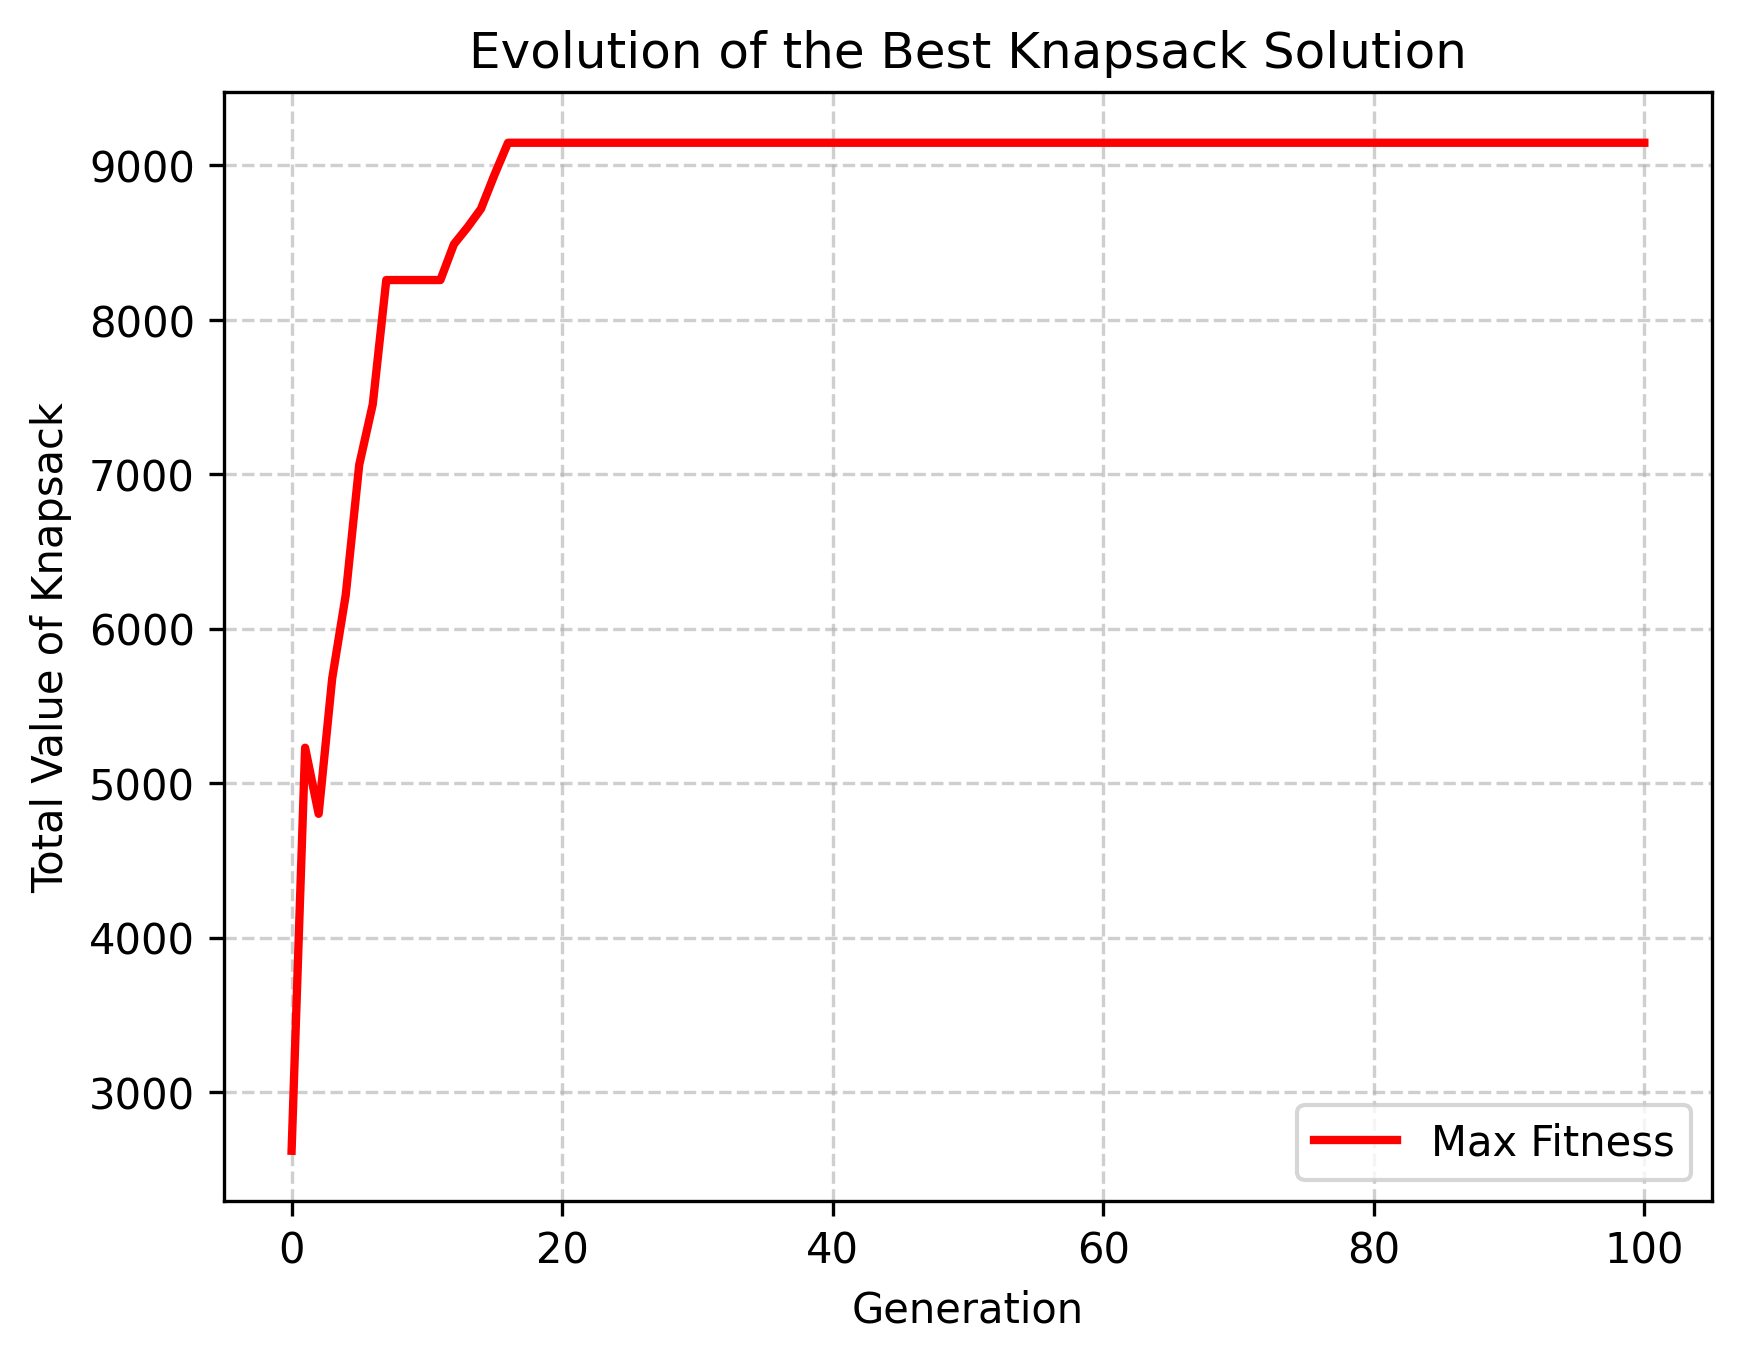








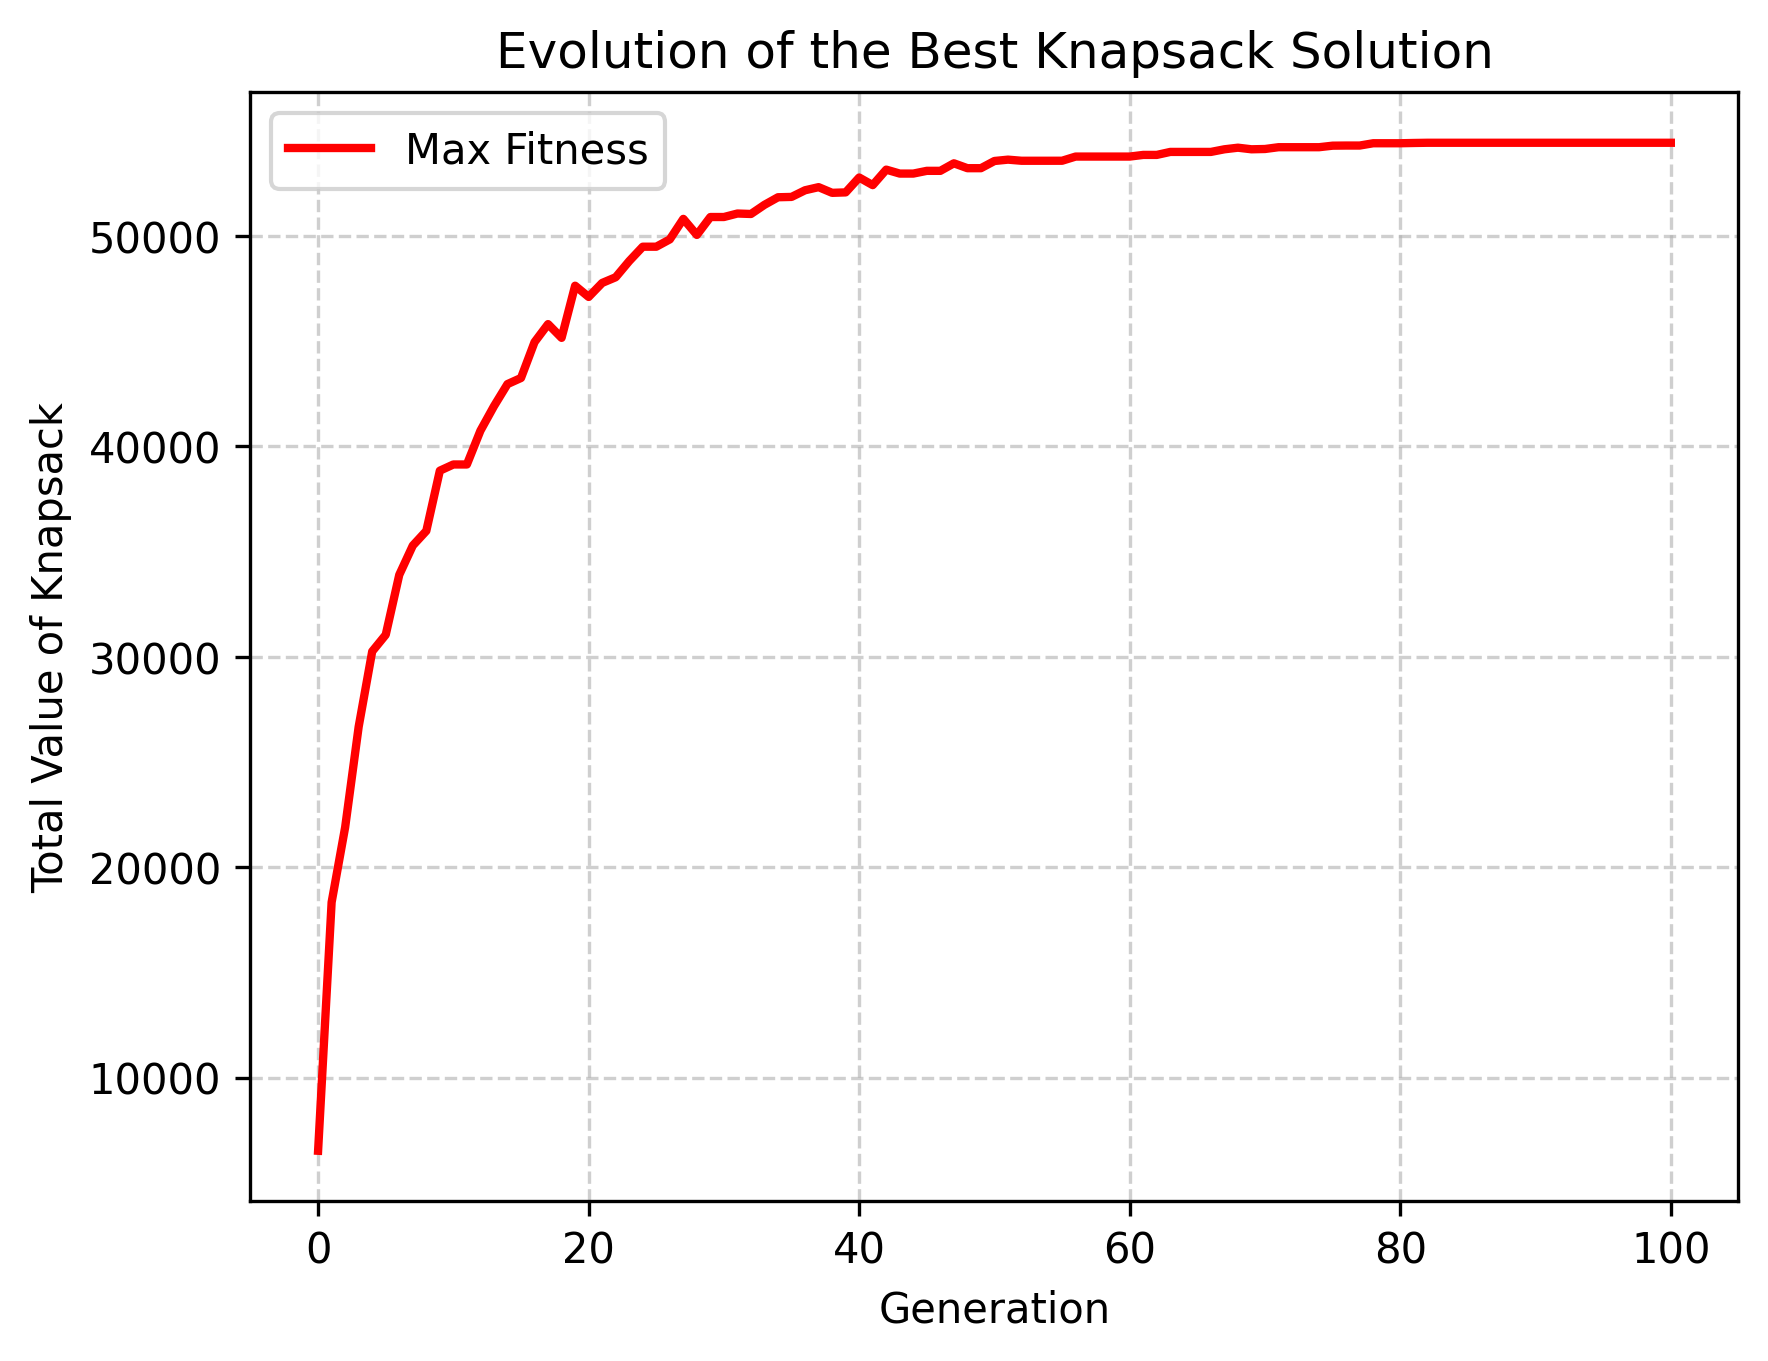